In [1]:
import pandas as pd

# load datasets
df = pd.read_csv("../data/ab_test.csv")
countries = pd.read_csv("../data/countries_ab.csv")

# merge on id
df = df.merge(countries, on="id")

df.head()

,id,time,con_treat,page,converted,country
0,851104,11:48.6,control,old_page,0,US
1,804228,01:45.2,control,old_page,0,US
2,661590,55:06.2,treatment,new_page,0,US
3,853541,28:03.1,treatment,new_page,0,US
4,864975,52:26.2,control,old_page,1,US


In [2]:
df = df.rename(columns={'con_treat': 'group'})

In [3]:
df.head()

,id,time,group,page,converted,country
0,851104,11:48.6,control,old_page,0,US
1,804228,01:45.2,control,old_page,0,US
2,661590,55:06.2,treatment,new_page,0,US
3,853541,28:03.1,treatment,new_page,0,US
4,864975,52:26.2,control,old_page,1,US


In [4]:
df.shape

(294478, 6)

In [5]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   id         294478 non-null  int64
 1   time       294478 non-null  str  
 2   group      294478 non-null  str  
 3   page       294478 non-null  str  
 4   converted  294478 non-null  int64
 5   country    294478 non-null  str  
dtypes: int64(2), str(4)
memory usage: 13.5 MB


,id,converted
count,294478.000000,294478.000000
mean,787974.124733,0.119659
std,91210.823776,0.324563
min,630000.000000,0.000000
25%,709032.250000,0.000000
50%,787933.500000,0.000000
75%,866911.750000,0.000000
max,945999.000000,1.000000


In [6]:
df.isnull().sum()

id           0
time         0
group        0
page         0
converted    0
country      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop_duplicates()

In [9]:
df.groupby('group')['converted'].mean()

group
control      0.120399
treatment    0.118920
Name: converted, dtype: float64

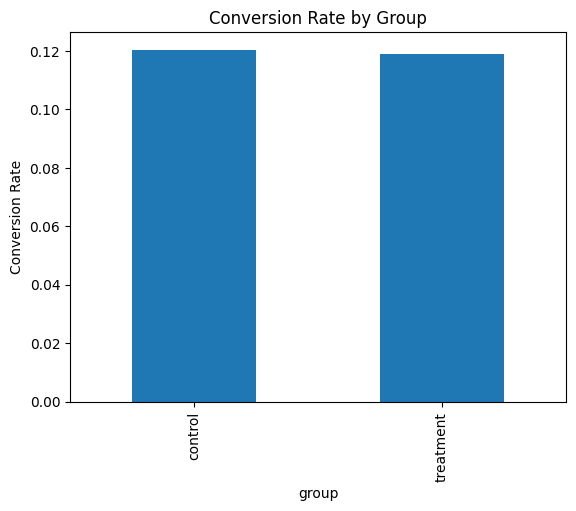

In [10]:
import matplotlib.pyplot as plt

df.groupby('group')['converted'].mean().plot(kind='bar')
plt.title("Conversion Rate by Group")
plt.ylabel("Conversion Rate")
plt.show()

In [11]:
df.groupby(['group', 'page']).size()

group      page    
control    new_page      1928
           old_page    145274
treatment  new_page    145311
           old_page      1965
dtype: int64

In [12]:
df['country'].value_counts(normalize=True)

country
US    0.700779
UK    0.249319
CA    0.049902
Name: proportion, dtype: float64

In [13]:
df.groupby(['country', 'group'])['converted'].mean()

country  group    
CA       control      0.119282
         treatment    0.112539
UK       control      0.120192
         treatment    0.120974
US       control      0.120552
         treatment    0.118649
Name: converted, dtype: float64

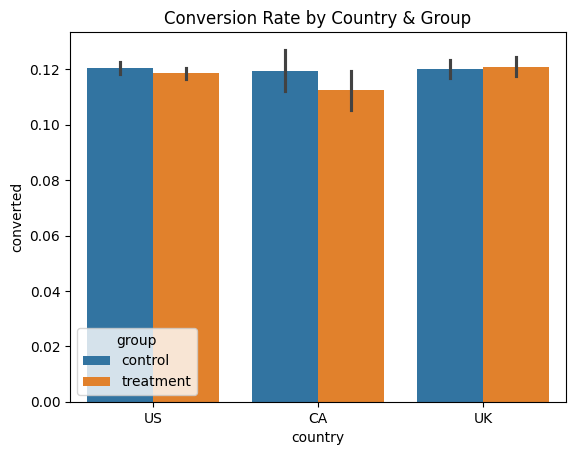

In [14]:
import seaborn as sns

sns.barplot(data=df, x='country', y='converted', hue='group')
plt.title("Conversion Rate by Country & Group")
plt.show()

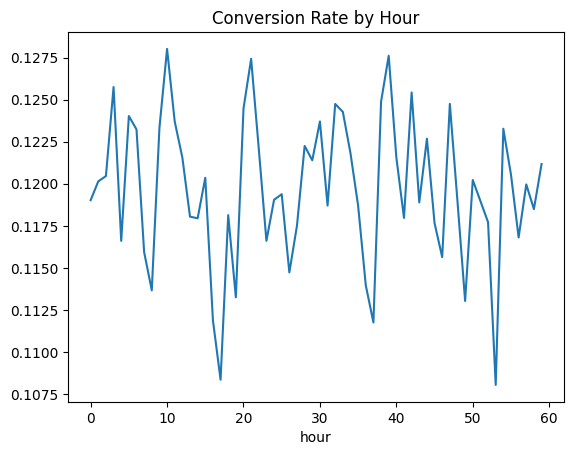

In [15]:
df['hour'] = df['time'].str.split(':').str[0].astype(int)

df.groupby('hour')['converted'].mean().plot()
plt.title("Conversion Rate by Hour")
plt.show()